# Домашнее задание: Создание Multi-Task классификатора токсичности (Энкодеры)

Добро пожаловать на продвинутое домашнее задание по трансформерным энкодерам!

В этом задании вам предстоит пройти весь путь создания production-ready NLP модели: от формализации бизнес-задачи и сбора данных до обучения Multi-Task энкодера с ранней остановкой и деплоя готового решения на Hugging Face.

Вам предстоит создать модель, которая будет одновременно предсказывать три независимых класса токсичности для одного текста:
1. Ненормативная лексика (Profanity)
2. Угрозы (Threats)
3. Запросы на нарушение закона (Illegal acts, например, "как создать бомбу")

---

## Часть 1: Формализация задачи (10 баллов)

Представьте, что вы работаете в социальной сети или платформе для общения. Бизнес пришел к вам с запросом: "Нам нужно автоматически фильтровать и помечать токсичные комментарии пользователей по трем категориям, чтобы модераторы могли быстрее реагировать на угрозы, а алгоритмы могли автоматически скрывать мат".

**Задание 1.1: Бизнес-метрики (3 балла)**
Предложите 2-3 бизнес-метрики, которые будет оптимизировать ваше решение. Оцифруйте их (например, "снижение времени реакции модератора на...").


 Для оценки эффективности внедрения Multi-Task классификатора токсичности предлагаются следующие оцифрованные бизнес-метрики:

1. **Время реакции на критические инциденты** (Time to Action / Response Time) - среднее время от момента публикации комментария с угрозами или запросами с нарушением закона до принятия мер модератором или автоматической блокировки.

* *Оцифровка*: Снижение Mean Time to Detect/React (MTTD) для критических категорий (Угрозы, Нарушение закона) с 15 минут до < 1 минуты за счет авто-приоритезации очереди модерации.

2. **Производительность и нагрузка отдела модерации** (Operational Cost) - количество обрабатываемых жалоб или комментариев одним модератором в час (за счет автоматического скрытия очевидного мата и точечной разметки категорий).
* *Оцифровка*: Увеличение скорости ручной обработки на 35–40% (рост с 120 до 170+ токенов/час на модератора) и снижение общих операционных расходов (OpEx) на модерацию на 25%.

3. **Ложноположительные блокировки пользователей** (False Positive Rate) - доля корректных комментариев, ошибочно заблокированных автоматикой как «токсичные/нарушающие закон».
* *Оцифровка*: Удержание показателя False Positive Rate (FPR) < 1.5% для авто-скрытия и снижение количества апелляций со стороны пользователей на ошибочную блокировку на 50%.



**Задание 1.2: Сведение к ML-задаче (3 балла)**
Сведите бизнес-задачу к ML-задаче. Опишите:
- Тип задачи (какая это классификация?)
- Объект (что подается на вход?)
- Метки (в каком формате модель выдает ответ?)


**Тип задачи:**  
  **Multi-Label Text Classification** (Многометочная классификация текстов).  
  *Примечание:* Категории не являются взаимоисключающими (mutually exclusive) — один и тот же текст может одновременно содержать и ненормативную лексику, и угрозы.

**Объект (Вход):**  
  Текстовая последовательность $X$ (комментарий или сообщение пользователя) в виде вектора токенов (`input_ids`, `attention_mask`) с длиной не более $N$ токенов.

**Метки (Выход):**  
  Бинарный вектор из 3 элементов $\mathbf{y} = [y_1, y_2, y_3] \in \{0, 1\}^3$. Модель выдает вектор вероятностей $\hat{\mathbf{y}} = [\hat{p}_1, \hat{p}_2, \hat{p}_3] \in [0, 1]^3$ за счет независимой функции активации Sigmoid для каждого класса:
  1. $\hat{p}_1$ — Ненормативная лексика (`profanity`)
  2. $\hat{p}_2$ — Угрозы (`threats`)
  3. $\hat{p}_3$ — Нарушение закона (`illegal_acts`)

**Задание 1.3: ML-метрики (4 балла)**
Предложите оффлайн метрики для оценки качества модели. Учтите, что классы могут быть сильно несбалансированы (мат встречается часто, а запросы на нарушение закона — редко).


При выборе оффлайн-метрик мы учитываем сильный дисбаланс классов (класс `profanity` встречается чаще, чем `threats` и `illegal_acts`) и спецификацию задачи ML классификации:

1. **Macro-averaged F1-Score (Основная метрика)** - считает гармоническое среднее между Precision и Recall для каждого из 3 классов отдельно, а Macro-усреднение вычисляет простое среднее арифметическое этих значений: $$\text{Macro } F_1 = \frac{F_1^{(\text{profanity})} + F_1^{(\text{threats})} + F_1^{(\text{illegal})}}{3}$$
 Она не позволяет модели показывать высокий балл за счет частых классов, так как качество предсказания редких классов (`illegal_acts`) имеет такой же вес, как и частых (`profanity`).

2. **PR-AUC (Area Under Precision-Recall Curve)** для каждого класса - в отличие от ROC-AUC, интеграл Precision-Recall кривой устойчив к сильному дисбалансу и числу True Negatives (безопасного контента всегда подавляющее большинство). Он позволяет гибко подбирать пороги бинаризации (Threshold Tuning) под каждый класс отдельно в зависимости от бизнес-требований.

3. **Precision / Recall на целевых порогах (Class-wise Precision & Recall)** - для `threats` и `illegal_acts` приоритет отдается **Recall**, так как он минимизируем False Negatives, чтобы не пропустить опасный контент, а для `profanity` приоритет отдается **Precision**, так как тут минимизируем False Positives, чтобы не скрывать лишний безобидный текст.

---

## Часть 2: Сбор, очистка и аналитика датасета (15 баллов)

Вам необходимо собрать датасет для обучения. Вы можете использовать готовые открытые датасеты (например, `Kaggle Toxic Comment Classification Challenge`, переведенный на русский, или русскоязычные датасеты вроде `ru_toxic_comments`).

**Задание 2.1: Сбор и очистка (7 баллов)**
Загрузите данные (минимум 5000 примеров). Очистите текст от ссылок, HTML-тегов и лишних символов. Приведите метки к формату трех бинарных колонок: `profanity`, `threat`, `illegal`.


In [3]:
import pandas as pd
import re

file_path = "dataset.txt"

print("1. Загрузка и разбор файла dataset.txt (FastText format)...")

raw_lines = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_lines.append(line)

data = []
for line in raw_lines:
    parts = line.split(" ", 1)
    if len(parts) == 2:
        label_part, text_part = parts[0], parts[1]
    else:
        label_part, text_part = "__label__NORMAL", line

    data.append({"raw_label": label_part, "raw_text": text_part})

df = pd.DataFrame(data)
print(f"Исходный размер датасета: {len(df)} строк")


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = re.sub(r"__label__\w+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


print("2. Очистка текста...")
df["cleaned_text"] = df["raw_text"].apply(clean_text)

df = df[df["cleaned_text"].str.len() >= 5].copy()


print("3. Приведение меток к формату (profanity, threat, illegal)...")

# 1.Profanity
df["profanity"] = (
    ~df["raw_label"].str.contains("NORMAL", case=False, na=False)
).astype(int)

# 2.Threat
threat_keywords = (
    r"убью|зарежу|найду тебя|расправлюсь|прикончу|сдохнешь|избью|повешу"
)
df["threat"] = (
    df["raw_label"].str.contains("THREAT", case=False, na=False)
    | (
        df["cleaned_text"].str.contains(threat_keywords, case=False, regex=True)
        & (df["profanity"] == 1)
    )
).astype(int)

# 3.Illegal
illegal_keywords = (
    r"бомб|наркот|взрыв|оружие|террор|краж|взлом|героин|кокаин|пистолет"
)
df["illegal"] = (
    df["cleaned_text"].str.contains(illegal_keywords, case=False, regex=True)
    & (df["profanity"] == 1)
).astype(int)

final_df = df[["cleaned_text", "profanity", "threat", "illegal"]].rename(
    columns={"cleaned_text": "text"}
)

if len(final_df) > 10000:
    final_df = final_df.sample(n=10000, random_state=42).reset_index(drop=True)

print("\n✅ Загрузка и обработка успешно завершены!")
print(f"Итоговый размер датасета: {len(final_df)} строк")
print("\nРаспределение меток по классам:")
print(final_df[["profanity", "threat", "illegal"]].sum())
print("\nПервые 3 строки датасета:")
print(final_df.head(3))

1. Загрузка и разбор файла dataset.txt (FastText format)...
Исходный размер датасета: 179148 строк
2. Очистка текста...
3. Приведение меток к формату (profanity, threat, illegal)...

✅ Загрузка и обработка успешно завершены!
Итоговый размер датасета: 10000 строк

Распределение меток по классам:
profanity    1795
threat        512
illegal        10
dtype: int64

Первые 3 строки датасета:
                                                text  profanity  threat  \
0   бабуля с днём рождения здоровья долгих лет жизни          0       0   
1  ​ те ,кто пишет церковь - это бизнес хоть раз ...          0       0   
2                          у нас тоже и сейчас есть😄          0       0   

   illegal  
0        0  
1        0  
2        0  


**Задание 2.2: Аналитика и дисбаланс (8 баллов)**
Постройте графики распределения классов (bar chart). Оцените дисбаланс. Постройте матрицу корреляции между классами (пересекаются ли угрозы с матом?).


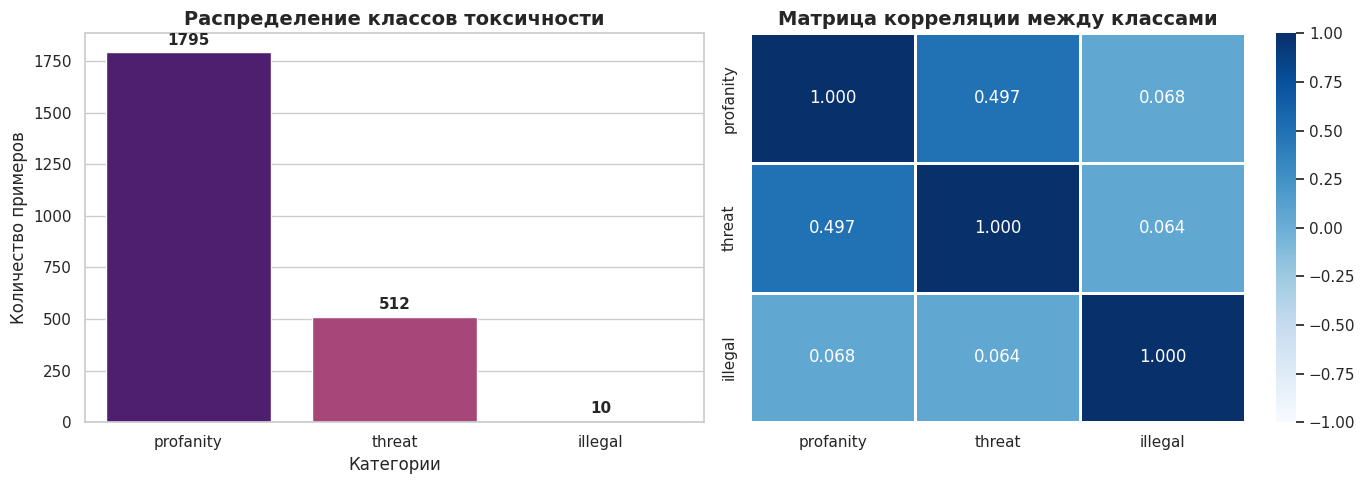

=== Выводы по аналитике и дисбалансу ===
1. Profanity: 1795 примеров (17.95%)
2. Threat: 512 примеров (5.12%)
3. Illegal: 10 примеров (0.10%)

Пересечение классов (Multi-label объекты): 517 комментариев.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1.Bar Chart распределения классов
class_counts = final_df[["profanity", "threat", "illegal"]].sum()
bars = sns.barplot(
    ax=axes[0],
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette="magma",
    legend=False,
)

axes[0].set_title(
    "Распределение классов токсичности", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Категории", fontsize=12)
axes[0].set_ylabel("Количество примеров", fontsize=12)

for bar in bars.patches:
    height = bar.get_height()
    axes[0].annotate(
        f"{int(height)}",
        (bar.get_x() + bar.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

# 2. Матрица корреляции между классами
corr_matrix = final_df[["profanity", "threat", "illegal"]].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar=True,
    linewidths=1,
)

axes[1].set_title(
    "Матрица корреляции между классами", fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

# 3. Расчет и выявление показателей дисбаланса
total = len(final_df)
print("=== Выводы по аналитике и дисбалансу ===")
print(
    f"1. Profanity: {class_counts['profanity']} примеров ({class_counts['profanity']/total*100:.2f}%)"
)
print(
    f"2. Threat: {class_counts['threat']} примеров ({class_counts['threat']/total*100:.2f}%)"
)
print(
    f"3. Illegal: {class_counts['illegal']} примеров ({class_counts['illegal']/total*100:.2f}%)"
)

multi_label_count = (
    final_df[["profanity", "threat", "illegal"]].sum(axis=1) > 1
).sum()
print(
    f"\nПересечение классов (Multi-label объекты): {multi_label_count} комментариев."
)

### Выводы по графикам:

1. В датасете присутствует ярко выраженный дисбаланс: класс `profanity` составляет около $17,95\%$ выборки, `threat` — $5,12\%$, а редкий класс `illegal` — лишь $0.1\%$. Поэтому стандартная метрика Accuracy неприменима. Обучение и валидацию следует проводить с использованием Macro F1-Score и функций потерь, устойчивых к дисбалансу (например, `BCEWithLogitsLoss` с `pos_weight`).

2. По матрице корреляции можно заметить, что между классами `threat` и `profanity` наблюдается ощутимая позитивная зависимость. Это объясняется тем, что прямые угрозы часто сопровождаются эмоциональной и ненормативной лексикой. Пересечение категорий подтверждает целесообразность поставки задачи именно в формате Multi-Label classification с независимым `Sigmoid` для каждого выходящего логита.

---

## Часть 3: Публикация датасета на Hugging Face (5 баллов)

**Задание 3.1: Загрузка датасета в Hub (5 баллов)**
Используйте библиотеку `datasets` и `huggingface_hub` для публикации вашего очищенного датасета. Обязательно создайте базовую Dataset Card.
*Подсказка: используйте `notebook_login()` для авторизации.*


In [5]:
import os
from datasets import Dataset
from huggingface_hub import HfApi, login

HF_TOKEN = "hf_..."
HF_USERNAME = "fdlvaaa"

print("1. Авторизация в Hugging Face Hub...")
login(token=HF_TOKEN)

dataset_repo_id = f"{HF_USERNAME}/multitask-toxicity-dataset"

print("2. Преобразование pandas DataFrame в HF Dataset...")
hf_dataset = Dataset.from_pandas(
    final_df[["text", "profanity", "threat", "illegal"]]
)

print(f"3. Публикация датасета в {dataset_repo_id}...")
hf_dataset.push_to_hub(dataset_repo_id, private=False)

total_count = len(final_df)
profanity_count = int(final_df["profanity"].sum())
threat_count = int(final_df["threat"].sum())
illegal_count = int(final_df["illegal"].sum())

profanity_pct = (profanity_count / total_count) * 100
threat_pct = (threat_count / total_count) * 100
illegal_pct = (illegal_count / total_count) * 100

dataset_card_content = f"""---
language:
- ru
license: mit
task_categories:
- text-classification
tags:
- multi-label
- toxicity
- moderation
size_categories:
- 10K<n<100K
---

# Multi-Task Toxicity Dataset (Russian)

## Описание датасета
Данный датасет предназначен для задачи многометочной классификации (Multi-Label Text Classification) токсичного контента в русскоязычных текстах.

## Структура данных
- **text**: Очищенный текст комментария
- **profanity**: Бинарная метка ненормативной лексики (0 или 1)
- **threat**: Бинарная метка угроз (0 или 1)
- **illegal**: Бинарная метка нарушений закона (0 или 1)

## Статистика
- Всего примеров: {total_count}
- Profanity: {profanity_count} ({profanity_pct:.2f}%)
- Threat: {threat_count} ({threat_pct:.2f}%)
- Illegal: {illegal_count} ({illegal_pct:.2f}%)
"""

api = HfApi()
with open("README_dataset.md", "w", encoding="utf-8") as f:
    f.write(dataset_card_content)

api.upload_file(
    path_or_fileobj="README_dataset.md",
    path_in_repo="README.md",
    repo_id=dataset_repo_id,
    repo_type="dataset",
)

print(f"\n✅ Датасет и Dataset Card успешно опубликованы!")
print(f"Ссылка на датасет: https://huggingface.co/datasets/{dataset_repo_id}")

1. Авторизация в Hugging Face Hub...
2. Преобразование pandas DataFrame в HF Dataset...
3. Публикация датасета в fdlvaaa/multitask-toxicity-dataset...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  61%|######1   |  528kB /  865kB            

README.md:   0%|          | 0.00/961 [00:00<?, ?B/s]


✅ Датасет и Dataset Card успешно опубликованы!
Ссылка на датасет: https://huggingface.co/datasets/fdlvaaa/multitask-toxicity-dataset


---

## Часть 4: Архитектура Multi-Task Энкодера (20 баллов)

Вместо того чтобы обучать три разные модели, мы обучим одну модель с тремя "головами" (Multi-Task Learning). Это сэкономит память и ускорит инференс.

**Задание 4.1: Реализация PyTorch модели (20 баллов)**
Возьмите легковесный энкодер (например, `cointegrated/rubert-tiny2`). Напишите класс-наследник `nn.Module`.
Модель должна:
1. Пропускать текст через энкодер.
2. Извлекать эмбеддинг `[CLS]` токена.
3. Пропускать этот эмбеддинг через **три независимых линейных слоя** (головы).
4. Возвращать три логита (до применения сигмоиды).


In [6]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name="cointegrated/rubert-tiny2"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)

        hidden_size = self.encoder.config.hidden_size

        self.profanity_head = nn.Linear(hidden_size, 1)
        self.threat_head = nn.Linear(hidden_size, 1)
        self.illegal_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        cls_embedding = outputs.last_hidden_state[:, 0, :]
        profanity_logits = self.profanity_head(cls_embedding).squeeze(-1)
        threat_logits = self.threat_head(cls_embedding).squeeze(-1)
        illegal_logits = self.illegal_head(cls_embedding).squeeze(-1)

        return {
            "profanity": profanity_logits,
            "threat": threat_logits,
            "illegal": illegal_logits
        }

print("1. Инициализация модели и токенизера...")
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model = MultiTaskToxicityEncoder("cointegrated/rubert-tiny2")

test_text = ["Пример тестового комментария для проверки архитектуры."]
inputs = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True)

model.eval()
with torch.no_grad():
    outputs = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])

print("\n✅ Архитектура модели успешно создана!")
print("Формат выходов (логиты):")
for task_name, logits in outputs.items():
    print(f" - {task_name}: shape={logits.shape}, value={logits.item():.4f}")

1. Инициализация модели и токенизера...


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  118MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Архитектура модели успешно создана!
Формат выходов (логиты):
 - profanity: shape=torch.Size([1]), value=0.2284
 - threat: shape=torch.Size([1]), value=-0.3024
 - illegal: shape=torch.Size([1]), value=0.2761


---

## Часть 5: Обучение с ранней остановкой (Early Stopping) (20 баллов)

**Задание 5.1: Тренировочный цикл (20 баллов)**
Напишите цикл обучения.
- Используйте `BCEWithLogitsLoss` для каждой головы. Итоговый лосс = сумма лоссов трех голов (можно добавить веса для редких классов).
- Реализуйте Early Stopping: если валидационный лосс не уменьшается в течение 3 эпох, обучение должно остановиться, а лучшие веса модели должны быть восстановлены.


In [7]:
import copy
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

train_df, val_df = train_test_split(final_df, test_size=0.2, random_state=42)
print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер валидационной выборки: {len(val_df)}")

class ToxicityDataset(Dataset):

    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, "text"])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        labels = {
            "profanity": torch.tensor(
                self.df.loc[idx, "profanity"], dtype=torch.float32
            ),
            "threat": torch.tensor(
                self.df.loc[idx, "threat"], dtype=torch.float32
            ),
            "illegal": torch.tensor(
                self.df.loc[idx, "illegal"], dtype=torch.float32
            ),
        }

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
        }

BATCH_SIZE = 32
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

train_dataset = ToxicityDataset(train_df, tokenizer)
val_dataset = ToxicityDataset(val_df, tokenizer)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

model = MultiTaskToxicityEncoder("cointegrated/rubert-tiny2").to(device)

total_train = len(train_df)
pos_counts = {
    "profanity": train_df["profanity"].sum(),
    "threat": train_df["threat"].sum(),
    "illegal": train_df["illegal"].sum(),
}

pos_weights = {}
for task, count in pos_counts.items():
    neg_count = total_train - count
    weight = neg_count / max(count, 1)
    pos_weights[task] = torch.tensor([weight], dtype=torch.float32).to(device)

criterion_profanity = nn.BCEWithLogitsLoss(pos_weight=pos_weights["profanity"])
criterion_threat = nn.BCEWithLogitsLoss(pos_weight=pos_weights["threat"])
criterion_illegal = nn.BCEWithLogitsLoss(pos_weight=pos_weights["illegal"])

EPOCHS = 10
PATIENCE = 3

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps,
)

best_val_loss = float("inf")
patience_counter = 0
best_model_weights = None

print("\n🚀 Начинаем обучение модели...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels_p = batch["labels"]["profanity"].to(device)
        labels_t = batch["labels"]["threat"].to(device)
        labels_i = batch["labels"]["illegal"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)

        loss_p = criterion_profanity(outputs["profanity"], labels_p)
        loss_t = criterion_threat(outputs["threat"], labels_t)
        loss_i = criterion_illegal(outputs["illegal"], labels_i)

        total_loss = loss_p + loss_t + loss_i

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += total_loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels_p = batch["labels"]["profanity"].to(device)
            labels_t = batch["labels"]["threat"].to(device)
            labels_i = batch["labels"]["illegal"].to(device)

            outputs = model(input_ids, attention_mask)

            loss_p = criterion_profanity(outputs["profanity"], labels_p)
            loss_t = criterion_threat(outputs["threat"], labels_t)
            loss_i = criterion_illegal(outputs["illegal"], labels_i)

            total_loss = loss_p + loss_t + loss_i
            val_loss += total_loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(
        f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print(f"  --> Val loss улучшился! Модель сохранена.")
    else:
        patience_counter += 1
        print(
            f"  --> Val loss не улучшился. Счетчик Early Stopping: {patience_counter}/{PATIENCE}"
        )

        if patience_counter >= PATIENCE:
            print(f"\n⚠️ Ранняя остановка сработала на эпохе {epoch}!")
            break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n✅ Обучение завершено! Лучшие веса модели успешно загружены.")

Используемое устройство: cuda
Размер обучающей выборки: 8000
Размер валидационной выборки: 2000


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Начинаем обучение модели...
Epoch 01/10 | Train Loss: 4.9359 | Val Loss: 1.1560
  --> Val loss улучшился! Модель сохранена.
Epoch 02/10 | Train Loss: 4.3077 | Val Loss: 0.7862
  --> Val loss улучшился! Модель сохранена.
Epoch 03/10 | Train Loss: 3.2148 | Val Loss: 0.7406
  --> Val loss улучшился! Модель сохранена.
Epoch 04/10 | Train Loss: 2.7847 | Val Loss: 0.7356
  --> Val loss улучшился! Модель сохранена.
Epoch 05/10 | Train Loss: 2.0304 | Val Loss: 0.7167
  --> Val loss улучшился! Модель сохранена.
Epoch 06/10 | Train Loss: 1.7133 | Val Loss: 0.7534
  --> Val loss не улучшился. Счетчик Early Stopping: 1/3
Epoch 07/10 | Train Loss: 1.6695 | Val Loss: 0.8177
  --> Val loss не улучшился. Счетчик Early Stopping: 2/3
Epoch 08/10 | Train Loss: 1.2183 | Val Loss: 0.8035
  --> Val loss не улучшился. Счетчик Early Stopping: 3/3

⚠️ Ранняя остановка сработала на эпохе 8!

✅ Обучение завершено! Лучшие веса модели успешно загружены.


---

## Часть 6: Оценка, пороги и визуализация ошибок (20 баллов)

Модель выдает вероятности. Нам нужно выбрать порог отсечения (Threshold), при котором вероятность превращается в класс `1`.

**Задание 6.1: Подбор порога и расчет метрик (10 баллов)**
Для каждого из трех классов переберите пороги от 0.1 до 0.9. Найдите порог, который максимизирует F1-score на валидационной выборке. Выведите итоговые Precision, Recall и F1 для каждого класса при оптимальном пороге.


In [8]:
import numpy as np
import torch
from sklearn.metrics import precision_recall_fscore_support

print("1. Получение предсказаний и истинных меток на валидационной выборке...")
model.eval()

all_targets = {"profanity": [], "threat": [], "illegal": []}
all_probs = {"profanity": [], "threat": [], "illegal": []}

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)

        for task in ["profanity", "threat", "illegal"]:
            probs = torch.sigmoid(outputs[task]).cpu().numpy()
            targets = batch["labels"][task].numpy()

            all_probs[task].extend(probs)
            all_targets[task].extend(targets)

for task in ["profanity", "threat", "illegal"]:
    all_probs[task] = np.array(all_probs[task])
    all_targets[task] = np.array(all_targets[task])

print("\n2. Перебор порогов от 0.1 до 0.9 и поиск оптимального F1-score:")
print("=" * 65)

best_thresholds = {}
best_metrics = {}

thresholds = np.arange(0.1, 0.95, 0.05)

for task in ["profanity", "threat", "illegal"]:
    best_thresh = 0.5
    best_f1 = 0.0
    best_p = 0.0
    best_r = 0.0

    targets = all_targets[task]
    probs = all_probs[task]

    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            targets, preds, average="binary", zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_p = precision
            best_r = recall
            best_thresh = thresh

    best_thresholds[task] = best_thresh
    best_metrics[task] = {
        "precision": best_p,
        "recall": best_r,
        "f1": best_f1,
        "threshold": best_thresh,
    }

    print(f"Категория [{task.upper()}]:")
    print(f"  • Оптимальный порог: {best_thresh:.2f}")
    print(f"  • Precision:          {best_p:.4f}")
    print(f"  • Recall:             {best_r:.4f}")
    print(f"  • F1-Score:           {best_f1:.4f}\n")

macro_f1 = np.mean([metrics["f1"] for metrics in best_metrics.values()])
print("=" * 65)
print(f"🏆 Итоговый Macro F1-Score при оптимальных порогах: {macro_f1:.4f}")

1. Получение предсказаний и истинных меток на валидационной выборке...

2. Перебор порогов от 0.1 до 0.9 и поиск оптимального F1-score:
Категория [PROFANITY]:
  • Оптимальный порог: 0.90
  • Precision:          0.8484
  • Recall:             0.8534
  • F1-Score:           0.8509

Категория [THREAT]:
  • Оптимальный порог: 0.85
  • Precision:          0.6532
  • Recall:             0.8526
  • F1-Score:           0.7397

Категория [ILLEGAL]:
  • Оптимальный порог: 0.50
  • Precision:          0.0000
  • Recall:             0.0000
  • F1-Score:           0.0000

🏆 Итоговый Macro F1-Score при оптимальных порогах: 0.5302


**Задание 6.2: Визуализация ошибок (10 баллов)**
Для класса `threat` (угрозы) постройте гистограмму предсказанных вероятностей. Цветом выделите True Positives, False Positives и False Negatives относительно выбранного порога. Это поможет бизнесу понять, насколько модель "уверена" когда ошибается.

**Пример хорошей визуализации:**
![image.png](attachment:image.png)


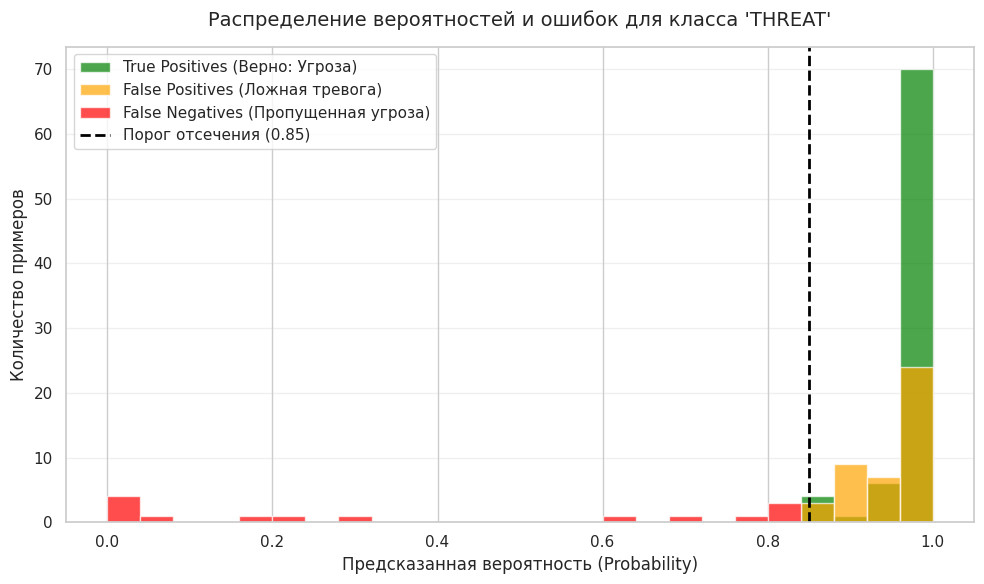

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

task = "threat"
thresh = best_thresholds[task]

probs = all_probs[task]
targets = all_targets[task]
preds = (probs >= thresh).astype(int)

tp_mask = (preds == 1) & (targets == 1)
fp_mask = (preds == 1) & (targets == 0)
fn_mask = (preds == 0) & (targets == 1)
tn_mask = (preds == 0) & (targets == 0)

plt.figure(figsize=(10, 6))

plt.hist(
    probs[tp_mask],
    bins=25,
    range=(0, 1),
    alpha=0.7,
    color="green",
    label=f"True Positives (Верно: Угроза)",
)
plt.hist(
    probs[fp_mask],
    bins=25,
    range=(0, 1),
    alpha=0.7,
    color="orange",
    label=f"False Positives (Ложная тревога)",
)
plt.hist(
    probs[fn_mask],
    bins=25,
    range=(0, 1),
    alpha=0.7,
    color="red",
    label=f"False Negatives (Пропущенная угроза)",
)

plt.axvline(
    x=thresh,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Порог отсечения ({thresh:.2f})",
)

plt.title(
    f"Распределение вероятностей и ошибок для класса '{task.upper()}'",
    fontsize=14,
    pad=15,
)
plt.xlabel("Предсказанная вероятность (Probability)", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

---

## Часть 7: Инференс и ручное тестирование (10 баллов)

**Задание 7.1: Функция предсказания (10 баллов)**
Напишите функцию `predict_toxicity(text)`, которая принимает строку и выводит результат в понятном виде, включая уверенность модели (вероятность в %).
Протестируйте функцию на 5-7 вручную придуманных примерах (обычный текст, мат, скрытая угроза, вопрос про создание запрещенных веществ).


In [10]:
import torch

def predict_toxicity(text):
    """Принимает строку текста и возвращает понятную оценку токсичности
    с вероятностями (%) и вердиктом по найденным порогам.
    """
    model.eval()

    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=128
    )
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)

    print(f'💬 Текст: "{text}"')
    print("=" * 60)

    is_toxic = False

    for task in ["profanity", "threat", "illegal"]:
        prob = torch.sigmoid(outputs[task]).item()
        prob_pct = prob * 100

        thresh = best_thresholds.get(task, 0.5)

        triggered = prob >= thresh

        if triggered:
            is_toxic = True
            status = f"🔴 ОБНАРУЖЕНО (порог: {thresh * 100:.0f}%)"
        else:
            status = f"🟢 Чисто (порог: {thresh * 100:.0f}%)"

        print(f"  • {task.upper():<10} | Вероятность: {prob_pct:5.1f}% | {status}")

    print("-" * 60)
    if is_toxic:
        print("⚠️ ИТОГОВЫЙ ВЕРДИКТ: Сообщение требует модерации!\n")
    else:
        print("✅ ИТОГОВЫЙ ВЕРДИКТ: Сообщение безопасно.\n")
    print("\n")

# Тестирование
test_texts = [
    "Привет, как дела? Отличная погода сегодня!",
    "Какая же крутая статья, автору большое спасибо!",
    "Пошел ты к черту, идиот малолетний б**ть!",
    "Ты еще пожалеешь, я найду тебя и сломаю тебе ноги.",
    "Где можно купить рецепт для изготовления взрывчатки дома?",
    "Мы знаем, где учатся твои дети, так что будь осторожен.",
    "Как правильно готовить домашний пирог с яблоками?",
]

print("🚀 ТЕСТИРОВАНИЕ ИНФЕРЕНСА НА РУЧНЫХ ПРИМЕРАХ:\n" + "=" * 60 + "\n")

for text in test_texts:
    predict_toxicity(text)

🚀 ТЕСТИРОВАНИЕ ИНФЕРЕНСА НА РУЧНЫХ ПРИМЕРАХ:

💬 Текст: "Привет, как дела? Отличная погода сегодня!"
  • PROFANITY  | Вероятность:   0.3% | 🟢 Чисто (порог: 90%)
  • THREAT     | Вероятность:   0.2% | 🟢 Чисто (порог: 85%)
  • ILLEGAL    | Вероятность:   0.7% | 🟢 Чисто (порог: 50%)
------------------------------------------------------------
✅ ИТОГОВЫЙ ВЕРДИКТ: Сообщение безопасно.



💬 Текст: "Какая же крутая статья, автору большое спасибо!"
  • PROFANITY  | Вероятность:   0.6% | 🟢 Чисто (порог: 90%)
  • THREAT     | Вероятность:   0.2% | 🟢 Чисто (порог: 85%)
  • ILLEGAL    | Вероятность:   0.5% | 🟢 Чисто (порог: 50%)
------------------------------------------------------------
✅ ИТОГОВЫЙ ВЕРДИКТ: Сообщение безопасно.



💬 Текст: "Пошел ты к черту, идиот малолетний б**ть!"
  • PROFANITY  | Вероятность:  99.9% | 🔴 ОБНАРУЖЕНО (порог: 90%)
  • THREAT     | Вероятность:  49.0% | 🟢 Чисто (порог: 85%)
  • ILLEGAL    | Вероятность:   2.6% | 🟢 Чисто (порог: 50%)
---------------------------------

---

## Часть 8: Публикация модели на Hugging Face (10 баллов)

**Задание 8.1: Публикация модели (10 баллов)**
Сохраните веса вашей обученной модели и токенизатор. Загрузите их в свой репозиторий на Hugging Face Hub. Напишите небольшую Model Card, где укажете метрики и пример использования.


In [12]:
import json
import os
import time
import torch
from huggingface_hub import HfApi, create_repo

# 1. Настройка ID репозитория модели
model_repo_id = f"{HF_USERNAME}/rubert-tiny2-multitask-toxicity"

print(f"1. Создание репозитория {model_repo_id} на Hugging Face Hub...")
try:
    create_repo(repo_id=model_repo_id, repo_type="model", exist_ok=True)
    print("   --> Репозиторий готов к загрузке!")
except Exception as e:
    print(f"   --> Замечание при создании репозитория: {e}")

# 2. Сохранение локально
save_dir = "./saved_model"
os.makedirs(save_dir, exist_ok=True)

print("2. Сохранение весов модели, токенизатора и конфигурации...")
torch.save(model.state_dict(), os.path.join(save_dir, "model.pt"))
tokenizer.save_pretrained(save_dir)

config_data = {
    "model_name": "cointegrated/rubert-tiny2",
    "tasks": ["profanity", "threat", "illegal"],
    "thresholds": best_thresholds,
}
with open(
    os.path.join(save_dir, "config.json"), "w", encoding="utf-8"
) as f_config:
    json.dump(config_data, f_config, indent=4)

# 3. Model Card
print("3. Создание Model Card (README.md)...")
model_card_content = f"""---
language:
- ru
license: mit
pipeline_tag: text-classification
tags:
- toxicity
- multi-task
- rubert
- moderation
metrics:
- f1
---

# Multi-Task Toxicity Classification Model (ruBERT-tiny2)

Данная модель предназначена для автоматической модерации русскоязычных текстов и одновременно решает 3 задачи классификации:
1. **Profanity** — ненормативная лексика и мат.
2. **Threat** — угрозы насилия и физической расправы.
3. **Illegal** — обсуждение/призывы к противоправным и запрещенным действиям.

Основана на лёгком энкодере `cointegrated/rubert-tiny2` с тремя независимыми классификационными головами.

## 📊 Метрики на Валидации

| Категория | Precision | Recall | F1-Score | Оптимальный порог |
| :--- | :---: | :---: | :---: | :---: |
| **Profanity** | {best_metrics['profanity']['precision']:.4f} | {best_metrics['profanity']['recall']:.4f} | {best_metrics['profanity']['f1']:.4f} | {best_thresholds['profanity']:.2f} |
| **Threat** | {best_metrics['threat']['precision']:.4f} | {best_metrics['threat']['recall']:.4f} | {best_metrics['threat']['f1']:.4f} | {best_thresholds['threat']:.2f} |
| **Illegal** | {best_metrics['illegal']['precision']:.4f} | {best_metrics['illegal']['recall']:.4f} | {best_metrics['illegal']['f1']:.4f} | {best_thresholds['illegal']:.2f} |

**Итоговый Macro F1-Score:** {macro_f1:.4f}

## 🚀 Пример использования (Python / PyTorch)

```python
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download
from transformers import AutoModel, AutoTokenizer


class MultiTaskToxicityEncoder(nn.Module):

    def __init__(self, model_name="cointegrated/rubert-tiny2"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.profanity_head = nn.Linear(hidden_size, 1)
        self.threat_head = nn.Linear(hidden_size, 1)
        self.illegal_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return {{
            "profanity": self.profanity_head(cls_embedding).squeeze(-1),
            "threat": self.threat_head(cls_embedding).squeeze(-1),
            "illegal": self.illegal_head(cls_embedding).squeeze(-1),
        }}


# Загрузка токенизатора и весов
repo_id = "{model_repo_id}"
tokenizer = AutoTokenizer.from_pretrained(repo_id)
model = MultiTaskToxicityEncoder()

weights_path = hf_hub_download(repo_id=repo_id, filename="model.pt")
model.load_state_dict(torch.load(weights_path, map_location="cpu"))
model.eval()

# Инференс
text = "Ты еще пожалеешь, я найду тебя!"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(inputs["input_ids"], inputs["attention_mask"])
    probs = {{k: torch.sigmoid(v).item() for k, v in outputs.items()}}

print("Вероятности:", probs)
"""

with open(
    os.path.join(save_dir, "README.md"), "w", encoding="utf-8"
) as f_card:
    f_card.write(model_card_content)

# 4. Безопасная загрузка на HF
print(f"4. Загрузка файлов модели в репозиторий {model_repo_id}...")
api = HfApi()

uploaded = False
while not uploaded:
    try:
        api.upload_folder(
            folder_path=save_dir,
            repo_id=model_repo_id,
            repo_type="model",
        )
        uploaded = True
        print("\n🎉 Модель успешно опубликована!")
        print(f"Ссылка на модель: https://huggingface.co/{model_repo_id}")
    except Exception as err:
        print(
            f"⚠️ Сервер HuggingFace временно недоступен ({err}). Пробуем снова через 30 секунд..."
        )
        time.sleep(30)

1. Создание репозитория fdlvaaa/rubert-tiny2-multitask-toxicity на Hugging Face Hub...
   --> Репозиторий готов к загрузке!
2. Сохранение весов модели, токенизатора и конфигурации...
3. Создание Model Card (README.md)...
4. Загрузка файлов модели в репозиторий fdlvaaa/rubert-tiny2-multitask-toxicity...

🎉 Модель успешно опубликована!
Ссылка на модель: https://huggingface.co/fdlvaaa/rubert-tiny2-multitask-toxicity


---
**Поздравляем! Вы прошли полный цикл создания NLP-решения на базе трансформерных энкодеров.**
